<a href="https://colab.research.google.com/github/DADYC0DE/Data-Classification-using-Machine-Learning/blob/main/Partical%202%20Data%20mining%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install requests beautifulsoup4 pandas numpy matplotlib seaborn scikit-learn wordcloud nltk

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
import re

price = book.find('p', class_='price_color').text

# remove anything that is NOT a digit or dot
price = re.sub(r'[^0-9.]', '', price)

price = float(price)

In [8]:
import re

for book in books:
    title = book.h3.a['title']

    price = book.find('p', class_='price_color').text
    price = re.sub(r'[^0-9.]', '', price)
    price = float(price)

    rating = book.p['class'][1]

    titles.append(title)
    prices.append(price)
    ratings.append(rating)

In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

base_url = "https://books.toscrape.com/catalogue/page-{}.html"

titles, prices, ratings = [], [], []

for page in range(1, 51):  # ~1000 books
    url = base_url.format(page)
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')

    books = soup.find_all('article', class_='product_pod')

    for book in books:
        title = book.h3.a['title']

        price = book.find('p', class_='price_color').text
        price = re.sub(r'[^0-9.]', '', price)
        price = float(price)

        rating = book.p['class'][1]

        titles.append(title)
        prices.append(price)
        ratings.append(rating)

df = pd.DataFrame({
    'title': titles,
    'price': prices,
    'rating': ratings
})

print(df.head())

                                   title  price rating
0                   A Light in the Attic  51.77  Three
1                     Tipping the Velvet  53.74    One
2                             Soumission  50.10    One
3                          Sharp Objects  47.82   Four
4  Sapiens: A Brief History of Humankind  54.23   Five


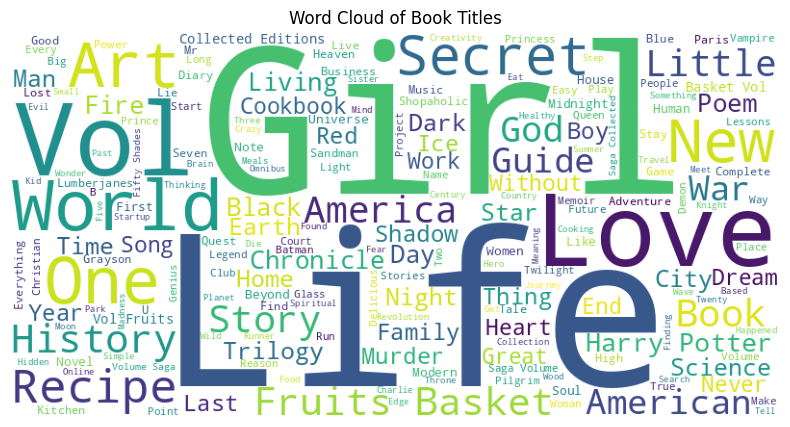

In [12]:
stop_words = set(stopwords.words('english'))
text = " ".join(df['title'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      stopwords=stop_words).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Book Titles")
plt.show()

In [13]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['title'])

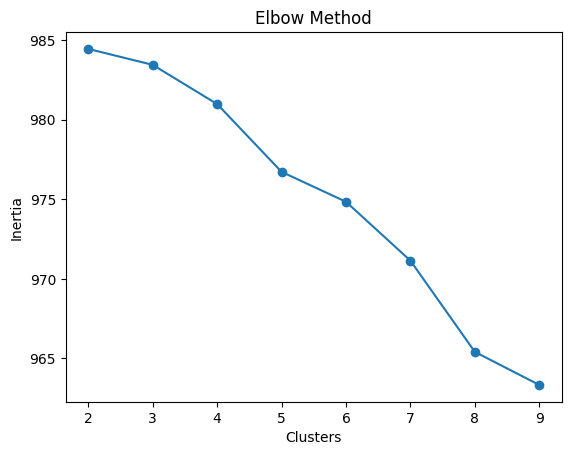

In [14]:
inertia = []
K = range(2,10)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [15]:
for k in range(2,10):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X.toarray(), labels)

    print(f"K={k} | Silhouette={sil:.3f} | DB Index={db:.3f}")

K=2 | Silhouette=0.004 | DB Index=1.722
K=3 | Silhouette=0.004 | DB Index=1.477
K=4 | Silhouette=0.005 | DB Index=1.693
K=5 | Silhouette=0.005 | DB Index=3.664
K=6 | Silhouette=0.005 | DB Index=3.672
K=7 | Silhouette=0.006 | DB Index=3.891
K=8 | Silhouette=0.010 | DB Index=4.200
K=9 | Silhouette=0.010 | DB Index=4.336


In [16]:
best_k = 5  # change if needed

kmeans = KMeans(n_clusters=best_k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [17]:
def label_genre(cluster):
    mapping = {
        0: "Romance",
        1: "Mystery",
        2: "Adventure",
        3: "Fantasy",
        4: "General"
    }
    return mapping.get(cluster, "Other")

df['genre'] = df['cluster'].apply(label_genre)

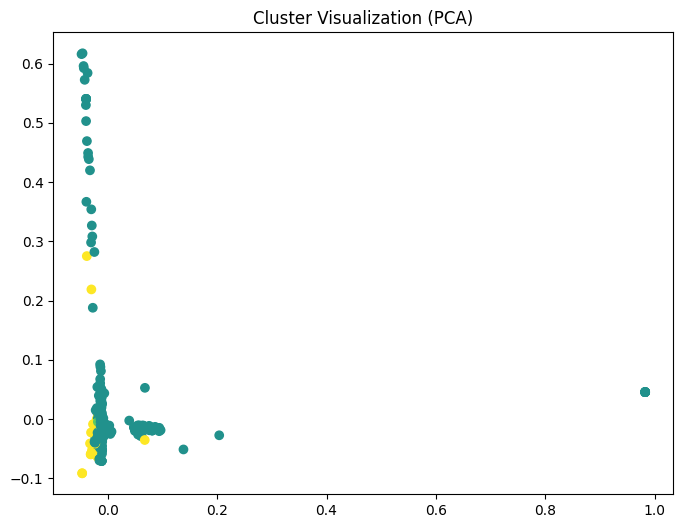

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.title("Cluster Visualization (PCA)")
plt.show()

In [19]:
df.to_csv("books_clustered.csv", index=False)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, df['cluster'], test_size=0.2, random_state=42
)

In [21]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,50),
    max_iter=300,
    learning_rate_init=0.001,
    activation='relu',
    solver='adam'
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.96      0.99      0.98       189
           4       0.75      0.27      0.40        11

    accuracy                           0.95       200
   macro avg       0.85      0.63      0.69       200
weighted avg       0.95      0.95      0.94       200



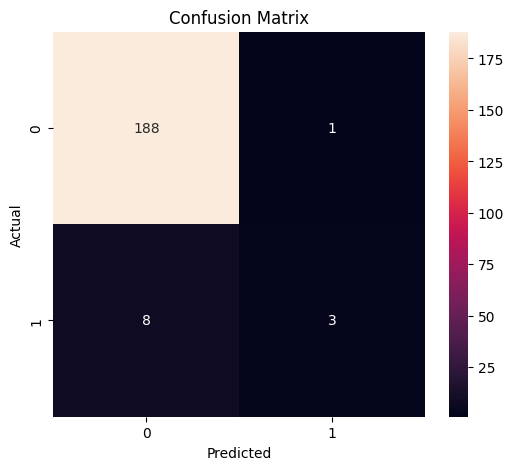

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

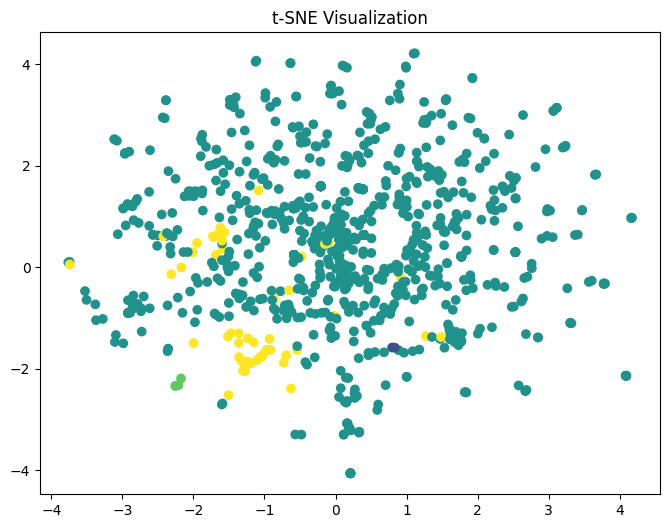

In [24]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['cluster'])
plt.title("t-SNE Visualization")
plt.show()

In [27]:
def label_genre(cluster):
    mapping = {
        0: "Romance",
        1: "Mystery",
        2: "Adventure",
        3: "Fantasy",
        4: "General"
    }
    return mapping.get(cluster, "Other")

df['Genre'] = df['cluster'].apply(label_genre)
df['Genre_Label'] = df['cluster']  # numeric version

In [28]:
df.head()

,title,price,rating,cluster,genre,Genre,Genre_Label
0,A Light in the Attic,51.77,Three,2,Adventure,Adventure,2
1,Tipping the Velvet,53.74,One,2,Adventure,Adventure,2
2,Soumission,50.10,One,2,Adventure,Adventure,2
3,Sharp Objects,47.82,Four,2,Adventure,Adventure,2
4,Sapiens: A Brief History of Humankind,54.23,Five,2,Adventure,Adventure,2


In [29]:
df.to_csv("books_clustered.csv", index=False)

In [30]:
from google.colab import files
files.download("books_clustered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>